# Classification Analysis: Predicting Marketing Campaign Response

### Project Context

This notebook addresses a binary classification problem in the context of a marketing campaign:
predicting whether a customer will respond positively to a campaign (`Response`).

Marketing campaigns are costly and operationally constrained.
Once a customer is contacted, the decision cannot be undone.
For this reason, the objective is not only predictive accuracy,
but making informed and cost-aware decisions under uncertainty.

This analysis is part of a broader customer analytics project
and focuses specifically on the decision layer of campaign targeting.

### Business Objective

The main business goals of this classification task are:

- Resource optimization  
  Campaign budgets are limited. Targeting customers with a higher probability of response
  improves return on investment (ROI).

- Customer experience protection  
  Repeatedly contacting uninterested customers leads to fatigue,
  lower engagement, and long-term brand damage.

- Strategic insight  
  Understanding which customer profiles are more likely to respond
  supports better campaign design and segmentation strategies.

### Key Challenges

This classification problem involves several non-trivial challenges.

- **Class imbalance**

Only a small proportion of customers respond to the campaign
(approximately 15%, around a 6:1 imbalance).
As a result, standard accuracy metrics can be misleading.

- **Asymmetric misclassification costs**

The cost of different prediction errors is not equal.

- False Negatives (missing a potential responder) lead to lost revenue
  and missed engagement opportunities.
- False Positives (contacting a non-responder) mainly incur marketing costs
  and are generally less severe.

- **Decision threshold dependency**

The default probability threshold of 0.5 is rarely optimal
in imbalanced and cost-sensitive classification problems.

For these reasons, this notebook emphasizes probability quality,
threshold optimization, and decision-aware evaluation,
rather than accuracy-based model selection.


## 1. Modeling Strategy and Evaluation Workflow

This notebook follows a structured and consistent modeling workflow.
Model performance and decision thresholds are treated as two separate steps.

### 1.1 Feature Availability Assumption

This modeling approach assumes that historical customer information
is available at the time of prediction.

The objective of this notebook is to optimize campaign targeting
for **known customers**, where past behavioral and engagement data
can be used to improve predictive performance.

For this reason, campaign history features (e.g. past campaign responses)
are included in the feature set. These variables are treated as valid
pre-campaign information rather than leakage.

The modeling strategy is therefore performance-oriented and focuses on
maximizing probability ranking quality under class imbalance.
A separate modeling scenario for new customers with limited information
is considered out of scope for this notebook.


### 1.2 Model Variants per Algorithm

For each classification algorithm, three variants are trained:

- Variant A: no class balancing  
- Variant B: class weighting using `class_weight="balanced"`  
- Variant C: SMOTE applied on training data only  

This setup allows a direct comparison between no balancing,
implicit balancing, and explicit resampling.

### 1.3 Initial Evaluation at Fixed Threshold

All model variants are first evaluated using a fixed threshold of 0.50.

At this stage:
- No threshold tuning is applied
- **PR-AUC is the primary comparison metric**, due to class imbalance
- Precision, recall, and F1 at t = 0.50 are reported for reference only

The purpose of this step is to assess probability ranking quality,
not to make final classification decisions.

### 1.4 Model Selection for Threshold Optimization

For each model family, only the variant with the strongest PR-AUC
is selected for further analysis.

Other variants are kept for documentation but are not tuned further.

### 1.5 Threshold Optimization

Threshold tuning is treated as a decision step after model training.

For the selected model:
- Predicted probabilities are fixed
- Performance is evaluated across a range of thresholds
- Thresholds are selected based on explicit objectives, such as:
  - Maximizing F1-score
  - Achieving a minimum precision level
  - Achieving a minimum recall level

This allows the same model to support different business goals
without retraining.

## 2. Technical Setup and Utilities

### 2.1 Imports

In [148]:
# ============================================================
# 📦 Core Scientific Stack
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# 📊 Visualization
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 📐 Statistics (optional / analysis support)
# ============================================================
import scipy.stats as stats

# ============================================================
# 🤖 Machine Learning — Data Splitting & Validation
# ============================================================
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

# ============================================================
# 🧱 Preprocessing & Pipelines
# ============================================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, FunctionTransformer,
PolynomialFeatures, RobustScaler )
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ============================================================
# ⚖️ Classification Models
# ============================================================
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC, SVC
from xgboost import XGBClassifier

# ============================================================
# ⚡ Imbalanced Learning
# ============================================================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ============================================================
# 📏 Evaluation Metrics
# ============================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# 🔍 Model Inspection & Interpretation
# ============================================================
from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay
)

# ============================================================
# 🛠 Utilities & Configuration
# ============================================================
import os
import re
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ============================================================
# 🎨 Project Styling
# ============================================================
MAIN_COLOR = "#B388EB"


### 2.2 Model Evaluation Utilities
This section defines reusable evaluation functions used across
all classification models in this notebook.

The goal is to ensure consistent metric computation, fair model comparison,
and clear visualization of classification performance under class imbalance.

In [112]:

RANDOM_STATE = 0

def metric_report(y_true, y_pred, y_proba=None, label="model"):
    # Basic metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    # Specificity (True Negative Rate)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    # ROC-AUC (if probabilities are provided)
    roc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    # PR-AUC
    if y_proba is not None:
        prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_proba)
        pr_auc = auc(rec_curve, prec_curve)
    else:
        pr_auc = None

    out = {
        "model": label,
        "accuracy": acc,
        "precision": prec,
        "specificity": spec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc,
        "pr_auc": pr_auc
    }
    return out

def plot_roc_pr(y_true, y_score, title_prefix=""):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    rocA = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    prA = auc(rec, prec)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={rocA:.3f}")
    plt.plot([0,1],[0,1],"--")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"{title_prefix} ROC"); plt.legend()
    plt.show()

    plt.figure()
    plt.plot(rec, prec, label=f"AP={prA:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"{title_prefix} Precision-Recall"); plt.legend()
    plt.show()

def show_confusion(y_true, y_pred, title="Confusion Matrix"):
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title(title); plt.show()

### 2.3 Threshold Optimization Utilities
This section defines reusable tools for selecting and evaluating
decision thresholds based on predicted probabilities.

Threshold optimization is treated as a post-modeling decision step
and is aligned with business objectives such as maximizing recall,
precision, or balanced performance.

In [114]:
# ============================================
# Threshold Optimization Tools (Steps A–C)
# ============================================

# =====================
# Step A — Threshold sweep
# =====================
def threshold_sweep(y_true, y_score, thresholds=None):
    """
    Sweep thresholds and compute metrics using metric_report.
    """
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)

    rows = []
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        m = metric_report(y_true, y_pred, y_score, label=f"t={t:.3f}")

        rows.append({
            "threshold": t,
            "accuracy":   m["accuracy"],
            "precision":  m["precision"],
            "specificity": m["specificity"],
            "recall":     m["recall"],
            "f1":         m["f1"],
            "roc_auc":    m["roc_auc"],
            "pr_auc":     m["pr_auc"],
        })
    return pd.DataFrame(rows)


# =====================
# Step B — Choose threshold by objective
# =====================
def choose_threshold_by_objective(sweep_df, objective="f1_max", target=0.8):

    if objective == "f1_max":
        i = sweep_df["f1"].idxmax()
        return float(sweep_df.loc[i, "threshold"]), "F1-max"

    if objective == "precision_at":
        df = sweep_df[sweep_df["precision"] >= target]
        if len(df) == 0:
            return float(sweep_df.iloc[-1]["threshold"]), f"precision_at({target}) — best available"
        i = df["recall"].idxmax()
        return float(df.loc[i, "threshold"]), f"precision≥{target}, max recall"

    if objective == "recall_at":
        df = sweep_df[sweep_df["recall"] >= target]
        if len(df) == 0:
            return float(sweep_df.iloc[-1]["threshold"]), f"recall_at({target}) — best available"
        i = df["precision"].idxmax()
        return float(df.loc[i, "threshold"]), f"recall≥{target}, max precision"

    raise ValueError("Unknown objective")


# =====================
# Step C — Evaluate model at chosen threshold
# =====================
#def show_at_threshold(y_true, y_score, t, label=""):
#   y_pred = (y_score >= t).astype(int)
#    show_confusion(y_true, y_pred, f"{label} (t={t:.2f})")
#    return metric_report(y_true, y_pred, y_score, f"{label} (t={t:.2f})")

# ============================================
def show_at_threshold(y_true, y_score, t, label=""):
    y_pred = (y_score >= t).astype(int)

    # Confusion matrix (normalized)
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(4, 4))

    # Base heatmap (no cmap meaning yet)
    im = ax.imshow(cm, vmin=0, vmax=1)

    # Define pastel colors
    green_pastel = "#C2E7C4"   # correct predictions
    red_pastel   = "#F0C6C3"   # incorrect predictions

    # Apply semantic coloring cell by cell
    for i in range(2):
        for j in range(2):
            if i == j:
                ax.add_patch(
                    plt.Rectangle(
                        (j - 0.5, i - 0.5),
                        1, 1,
                        facecolor=green_pastel,
                        edgecolor="white"
                    )
                )
            else:
                ax.add_patch(
                    plt.Rectangle(
                        (j - 0.5, i - 0.5),
                        1, 1,
                        facecolor=red_pastel,
                        edgecolor="white"
                    )
                )

            ax.text(
                j, i,
                f"{cm[i, j]:.0f}",
                ha="center", va="center",
                fontsize=11,
                color="black"
            )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"], fontsize=9)
    ax.set_yticklabels(["True 0", "True 1"], fontsize=9)

    ax.set_title(f"{label}\n(t = {t:.2f})", fontsize=10)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)

    plt.tight_layout()
    plt.show()

    return metric_report(y_true, y_pred, y_score, f"{label} (t={t:.2f})")


 ### 2.4 IQR-Based Outlier Handling Utilities

In [115]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class IQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, k=1.5):
        self.k = k

    def fit(self, X, y=None):
        # Ensure DataFrame for column-wise operations
        X = pd.DataFrame(X)

        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1

        self.lower_bounds_ = q1 - self.k * iqr
        self.upper_bounds_ = q3 + self.k * iqr

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        for col in X.columns:
            X[col] = X[col].clip(
                lower=self.lower_bounds_[col],
                upper=self.upper_bounds_[col]
            )

        return X


## 3. Data Preparation and Pipeline-Based Preprocessing

### 3.1 Load Raw Data
- Load the cleaned modeling dataset
- Define the binary target variable: `Response`

In [116]:
# Load raw marketing campaign dataset
df = pd.read_csv('Data/marketing_campaign.csv', sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [117]:
df.groupby(['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4',
              'AcceptedCmp5']).agg({'Response':['count','sum']})

Response     
                                                                    count  sum
AcceptedCmp1 AcceptedCmp2 AcceptedCmp3 AcceptedCmp4 AcceptedCmp5              
0            0            0            0            0                1777  146
                                                    1                  59   21
                                       1            0                  84   11
                                                    1                  24   12
                          1            0            0                 129   55
                                                    1                   6    2
             1            0            0            0                   1    1
                                       1            0                   8    3
                                                    1                   4    2
                          1            0            0                   2    0
                                                    1                   2    2
1            0            0            0            0                  52   13
                                                    1                  21   14
                                       1            0                  14    6
                                                    1                  23   19
                          1            0            0                   8    5
                                                    1                  13   10
             1            0            1            0                   2    2
                                                    1                   8    7
                          1            0            1                   3    3

Exploratory analysis of campaign history reveals that prior campaign acceptance
is a strong predictor of future response. Customers with no previous acceptance
exhibit a response rate below 10%, while customers with at least one prior
acceptance show substantially higher response probabilities.

Including campaign history features significantly improves probability ranking
performance. However, the model primarily distinguishes between historically
responsive and non-responsive customers.

### 3.2 Basic Data Cleaning

Only minimal data cleaning is performed at this stage, including
type corrections (e.g. date fields).

A more extensive exploratory data analysis (EDA) was previously conducted
on the full dataset and is documented in a separate notebook
([eda.ipynb](eda.ipynb)).
Insights from that analysis informed feature selection and modeling decisions,
but the analysis itself is not repeated here.

In [118]:
# ----------------------------------
# 2.2 Basic Data Cleaning
# ----------------------------------

# Convert customer registration date to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)


### 3.3 Train / Test Split

In [119]:
# ----------------------------------
# 1.4 Train / Test Split
# ----------------------------------

# Define target (binary classification)
y = df["Response"]

# Define feature matrix
X = df.drop(columns=["Response"])

# Perform stratified train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Sanity check
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((1792, 28), (448, 28), (1792,), (448,))

### 3.4 Deterministic Feature Construction 
*(Custom Transformer – Leakage-Safe)*

In [120]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class DeterministicFeatureBuilder(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        self.reference_year_ = X["Dt_Customer"].dt.year.max()
        self.reference_date_ = X["Dt_Customer"].max()
        return self

    def transform(self, X):
        X_ = X.copy()

        # ------------------
        # Temporal features
        # ------------------
        X_["Age"] = self.reference_year_ - X_["Year_Birth"]

        X_["Tenure_Days"] = (self.reference_date_ - X_["Dt_Customer"]).dt.days
        X_["Tenure_Months"] = (X_["Tenure_Days"] / 30).round().astype(int)

        # ------------------
        # Household & demographic
        # ------------------
        X_["Marital_Status"] = X_["Marital_Status"].replace(
            ['Alone', 'Absurd', 'YOLO'], 'Other'
        )

        X_["HasChildren"] = ((X_["Kidhome"] + X_["Teenhome"]) > 0).astype(int)

        X_["FamilySize"] = (
            X_["Marital_Status"].isin(['Married', 'Together']).astype(int) + 1
            + X_["Kidhome"] + X_["Teenhome"]
        )

        # ------------------
        # Education
        # ------------------
        education_map = {
            'Basic': 1, '2n Cycle': 2,
            'Graduation': 3, 'Master': 4, 'PhD': 5
        }

        X_["Education_Level"] = X_["Education"].map(education_map)

        X_["Education_Level_Grouped"] = pd.cut(
            X_["Education_Level"],
            bins=[0, 2, 4, 5],
            labels=["Low", "Medium", "High"]
        )

        # ------------------
        # Spending behavior
        # ------------------
        spend_cols = [
            'MntWines','MntFruits','MntMeatProducts',
            'MntFishProducts','MntSweetProducts','MntGoldProds'
        ]
        X_["TotalSpend"] = X_[spend_cols].sum(axis=1)

        # ------------------
        # Purchase behavior
        # ------------------
        purchase_cols = [
            'NumWebPurchases','NumCatalogPurchases','NumStorePurchases'
        ]
        X_["TotalPurchases"] = X_[purchase_cols].sum(axis=1)

        # ------------------
        # Campaign behavior
        # ------------------
        accepted_cols = [
            'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
            'AcceptedCmp4','AcceptedCmp5'
        ]
        X_["TotalAccepted"] = X_[accepted_cols].sum(axis=1)

        return X_


### 3.5 Feature Group Definition

In [125]:
# ----------------------------------
# Feature groups — Classification
# ----------------------------------

# ============================================================
# 1) Numeric continuous features
# - Real-valued, ordered
# - Scaled but NOT log-transformed
# ============================================================

numeric_continuous_cols = [
    "Income",
    "Age",
    "Tenure_Days",
    "Recency"
]


# ============================================================
# 2) Numeric household & count-based features
# - Discrete counts / derived quantities
# - Kept on original scale or lightly scaled
# ============================================================

numeric_household_cols = [
    "Kidhome",
    "Teenhome",
    "NumWebPurchases",
    "NumStorePurchases",
    "NumCatalogPurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth"
]


# ============================================================
# 3) Special numeric feature (log-transformed only)
# - Strongly right-skewed
# - Transformed INSIDE pipeline to avoid leakage
# ============================================================

numeric_log_cols = [
    "TotalSpend"
]


# ============================================================
# 4) Binary features (0/1)
# - Already encoded
# ============================================================

binary_cols = [
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]


# ============================================================
# 5) Categorical profile features
# - Low cardinality
# - One-hot encoded
# ============================================================

categorical_cols = [
    "Education",
    "Marital_Status"
]


### 3.6 Preprocessing Pipelines
- Imputation
- IQR-based capping
- Log transformation (where applicable)
- Scaling
- Encoding

In [149]:
# ============================================================
# 3.7 Preprocessing Pipelines by Model Family — Classification
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
import numpy as np

# ============================================================
# Family 1 — Logistic Regression
# ============================================================

logistic_pipelines = {
    "numeric_continuous": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("capper", IQRCapper()),
        ("scaler", StandardScaler())
    ]),
    "numeric_household": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]),
    "numeric_log": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p)),
        ("scaler", StandardScaler())
    ]),
    "binary": "passthrough",
    "categorical": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ])
}

# ============================================================
# Family 2 — Support Vector Machines (SVM)
# ============================================================

svm_pipelines = {
    "numeric_continuous": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("capper", IQRCapper()),
        ("scaler", StandardScaler())
    ]),
    "numeric_household": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]),
    "numeric_log": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p)),
        ("scaler", StandardScaler())
    ]),
    "binary": "passthrough",
    "categorical": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ])
}

# ============================================================
# Family 3 — Decision Tree Models
# ============================================================

tree_pipelines = {
    "numeric_continuous": Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]),
    "numeric_household": Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]),
    "numeric_log": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p))
    ]),
    "binary": "passthrough",
    "categorical": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
}

# ============================================================
# Family 4 — Random Forest Models
# ============================================================

forest_pipelines = {
    "numeric_continuous": Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]),
    "numeric_household": Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]),
    "numeric_log": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p))
    ]),
    "binary": "passthrough",
    "categorical": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
}

# ============================================================
# Family 5 — Polynomial feature pipeline (degree=2, interactions only)
# ============================================================

poly_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("capper", IQRCapper()),
    ("poly", PolynomialFeatures(
        degree=2,
        interaction_only=True,
        include_bias=False
    )),
    ("scaler", RobustScaler())
])


### 3.7 ColumnTransformer

In [150]:
# ============================================================
# 3.8 Preprocessors (ColumnTransformer) by Model Family — Classification
# ============================================================

from sklearn.compose import ColumnTransformer

# ============================================================
# Preprocessor — Logistic Regression Family
# ============================================================

preprocessor_logistic = ColumnTransformer(
    transformers=[
        ("num_cont", logistic_pipelines["numeric_continuous"], numeric_continuous_cols),
        ("num_house", logistic_pipelines["numeric_household"], numeric_household_cols),
        ("num_log", logistic_pipelines["numeric_log"], numeric_log_cols),
        ("binary", logistic_pipelines["binary"], binary_cols),
        ("cat", logistic_pipelines["categorical"], categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ============================================================
# Preprocessor — SVM Family
# ============================================================

preprocessor_svm = ColumnTransformer(
    transformers=[
        ("num_cont", svm_pipelines["numeric_continuous"], numeric_continuous_cols),
        ("num_house", svm_pipelines["numeric_household"], numeric_household_cols),
        ("num_log", svm_pipelines["numeric_log"], numeric_log_cols),
        ("binary", svm_pipelines["binary"], binary_cols),
        ("cat", svm_pipelines["categorical"], categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ============================================================
# Preprocessor — Decision Tree Family
# ============================================================

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num_cont", tree_pipelines["numeric_continuous"], numeric_continuous_cols),
        ("num_house", tree_pipelines["numeric_household"], numeric_household_cols),
        ("num_log", tree_pipelines["numeric_log"], numeric_log_cols),
        ("binary", tree_pipelines["binary"], binary_cols),
        ("cat", tree_pipelines["categorical"], categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ============================================================
# Preprocessor — Random Forest Family
# ============================================================

preprocessor_forest = ColumnTransformer(
    transformers=[
        ("num_cont", forest_pipelines["numeric_continuous"], numeric_continuous_cols),
        ("num_house", forest_pipelines["numeric_household"], numeric_household_cols),
        ("num_log", forest_pipelines["numeric_log"], numeric_log_cols),
        ("binary", forest_pipelines["binary"], binary_cols),
        ("cat", forest_pipelines["categorical"], categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ============================================================
# ColumnTransformer — Polynomial Logistic Regression
# ============================================================

preprocessor_poly_logistic = ColumnTransformer(
    transformers=[
        ("num_cont", poly_pipeline, numeric_continuous_cols),
        ("num_house", poly_pipeline, numeric_household_cols),
        ("num_log", poly_pipeline, numeric_log_cols),
        ("binary", "passthrough", binary_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


In [129]:
preprocessor_logistic

,transformers,"[('num_cont', ...), ('num_house', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [130]:
preprocessor_svm

,transformers,"[('num_cont', ...), ('num_house', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [131]:
preprocessor_tree

,transformers,"[('num_cont', ...), ('num_house', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [132]:
preprocessor_forest 

,transformers,"[('num_cont', ...), ('num_house', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [151]:
preprocessor_poly_logistic

,transformers,"[('num_cont', ...), ('num_house', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 4. Modeling Strategy and Evaluation

## 4.1 Model 1 — Logistic Regression (Baseline)

This section evaluates logistic regression as the baseline model for predicting
campaign response.

Three variants are considered:
- **Model 1a — Logistic (no regularization)**  
- **Model 1b — Logistic with L2 regularization (CV)**  
- **Model 1c — Logistic with L1 regularization (CV)**  

All models handle class imbalance via **class weighting** and use the same
preprocessing pipeline.

Models are evaluated on the held-out test set using a fixed threshold of `t = 0.50`.
Model comparison focuses on **PR-AUC**, while other metrics are reported for reference.
Threshold optimization is performed in a separate section.


In [133]:
# ==========================================
# Model 1 — Logistic Regression (Balanced)
#   1a) Logistic (no regularization)
#   1b) Logistic + L2 (CV)
#   1c) Logistic + L1 (CV)
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

rows = []

# ============================================================
# 1a) Logistic Regression — no regularization
# ============================================================

pipe_logit_1a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_logistic),   # 🔒 LOCKED
    ("classifier", LogisticRegression(
        penalty=None,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=2000
    ))
])

pipe_logit_1a.fit(X_train, y_train)

y_pred_1a  = pipe_logit_1a.predict(X_test)
y_proba_1a = pipe_logit_1a.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_1a,
        y_proba_1a,
        label="Model 1a — Logistic (balanced, no regularization)"
    )
)

# ============================================================
# 1b) Logistic Regression — L2 regularization (CV)
# ============================================================

pipe_logit_1b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_logistic),   # 🔒 LOCKED
    ("classifier", LogisticRegressionCV(
        Cs=10,
        cv=5,
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
        scoring="average_precision",
        max_iter=2000,
        n_jobs=-1
    ))
])

pipe_logit_1b.fit(X_train, y_train)

y_pred_1b  = pipe_logit_1b.predict(X_test)
y_proba_1b = pipe_logit_1b.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_1b,
        y_proba_1b,
        label="Model 1b — Logistic L2 (balanced, CV)"
    )
)

# ============================================================
# 1c) Logistic Regression — L1 regularization (CV)
# ============================================================

pipe_logit_1c = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_logistic),   # 🔒 LOCKED
    ("classifier", LogisticRegressionCV(
        Cs=10,
        cv=5,
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        scoring="average_precision",
        max_iter=2000,
        n_jobs=-1
    ))
])

pipe_logit_1c.fit(X_train, y_train)

y_pred_1c  = pipe_logit_1c.predict(X_test)
y_proba_1c = pipe_logit_1c.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_1c,
        y_proba_1c,
        label="Model 1c — Logistic L1 (balanced, CV)"
    )
)

# ============================================================
# Compact comparison table
# ============================================================

df_model1_compare = pd.DataFrame(rows)
display(df_model1_compare)


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,"Model 1a — Logistic (balanced, no regularization)",0.825893,0.453782,0.829396,0.80597,0.580645,0.895150,0.639690
1,"Model 1b — Logistic L2 (balanced, CV)",0.823661,0.450000,0.826772,0.80597,0.577540,0.895738,0.642339
2,"Model 1c — Logistic L1 (balanced, CV)",0.823661,0.450000,0.826772,0.80597,0.577540,0.894915,0.639713


### 4.1.1 Decision Threshold Optimization (Model 1b)
Predicted probabilities are fixed and evaluated across multiple thresholds
to support different business objectives.

,threshold,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,0.01,0.212,0.160,0.073,1.0,0.275,0.896,0.642
1,0.02,0.263,0.169,0.134,1.0,0.289,0.896,0.642
2,0.03,0.295,0.175,0.171,1.0,0.298,0.896,0.642
3,0.04,0.346,0.186,0.231,1.0,0.314,0.896,0.642
4,0.05,0.382,0.195,0.273,1.0,0.326,0.896,0.642


F1-optimal threshold: 0.65 (F1-max)
Precision≥0.70 threshold: 0.93 (precision≥0.7, max recall)
Recall≥0.70 threshold: 0.65 (recall≥0.7, max precision)


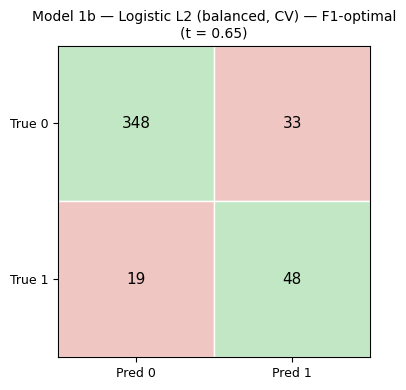

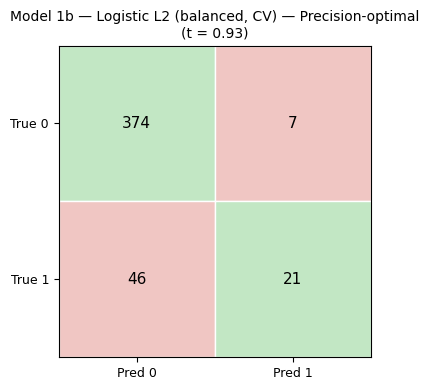

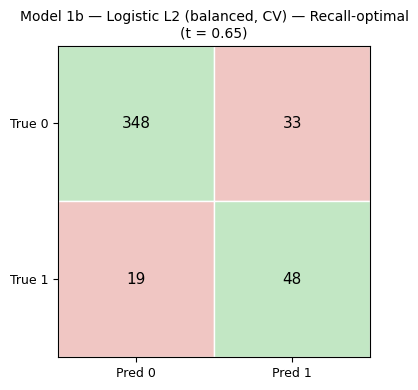


F1-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,"Model 1b — Logistic L2 (balanced, CV) — F1-opt...",0.8839,0.5926,0.9134,0.7164,0.6486,0.8957,0.6423



Precision-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,"Model 1b — Logistic L2 (balanced, CV) — Precis...",0.8817,0.75,0.9816,0.3134,0.4421,0.8957,0.6423



Recall-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,"Model 1b — Logistic L2 (balanced, CV) — Recall...",0.8839,0.5926,0.9134,0.7164,0.6486,0.8957,0.6423


In [134]:
# ============================================
# Threshold Optimization — Model Selection
# ============================================

# Select model for threshold optimization
y_proba_best = y_proba_1b
model_label  = "Model 1b — Logistic L2 (balanced, CV)"
# ----------------------------------

# ============================================
# Threshold Optimization
# ============================================

# ---------------------
# Step D — Threshold sweep
# ---------------------
sweep_df = threshold_sweep(y_test, y_proba_best)

# Display preview only (do NOT round real values)
display(sweep_df.round(3).head())

# ---------------------
# Step E — Select thresholds by objective
# ---------------------
t_f1, name_f1 = choose_threshold_by_objective(
    sweep_df, objective="f1_max"
)

t_prec, name_prec = choose_threshold_by_objective(
    sweep_df, objective="precision_at", target=0.70
)

t_rec, name_rec = choose_threshold_by_objective(
    sweep_df, objective="recall_at", target=0.70
)

print(f"F1-optimal threshold: {t_f1:.2f} ({name_f1})")
print(f"Precision≥0.70 threshold: {t_prec:.2f} ({name_prec})")
print(f"Recall≥0.70 threshold: {t_rec:.2f} ({name_rec})")

# ---------------------
# Step F — Evaluation at selected thresholds
# ---------------------
res_f1 = show_at_threshold(
    y_test, y_proba_best, t_f1,
    f"{model_label} — F1-optimal"
)

res_prec = show_at_threshold(
    y_test, y_proba_best, t_prec,
    f"{model_label} — Precision-optimal"
)

res_rec = show_at_threshold(
    y_test, y_proba_best, t_rec,
    f"{model_label} — Recall-optimal"
)

# ---------------------
# Summary tables
# ---------------------
print("\nF1-optimal threshold metrics:")
display(pd.DataFrame([res_f1]).round(4))

print("\nPrecision-optimal threshold metrics:")
display(pd.DataFrame([res_prec]).round(4))

print("\nRecall-optimal threshold metrics:")
display(pd.DataFrame([res_rec]).round(4))


## 4.2 Model 2 — Support Vector Machines

This section evaluates Support Vector Machine (SVM) classifiers as
margin-based alternatives to logistic regression.

Two variants are considered:
- **Model 2a — Linear SVC**
- **Model 2b — SVC with RBF kernel**

All models use the same preprocessing pipeline and handle class imbalance
via class weighting. Evaluation is performed on the test set at a fixed
threshold of `t = 0.50` prior to threshold optimization.
Probability estimates are enabled for SVM models to allow PR-AUC evaluation and decision threshold optimization.


In [135]:
# ==========================================
# Model 2 — Support Vector Machines (Balanced)
#   2a) Linear SVM
#   2b) RBF SVM
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

rows = []

# ============================================================
# 2a) Linear SVM
# ============================================================

pipe_svm_2a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_svm),   # 🔒 LOCKED
    ("classifier", SVC(
        kernel="linear",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

pipe_svm_2a.fit(X_train, y_train)

y_pred_2a  = pipe_svm_2a.predict(X_test)
y_proba_2a = pipe_svm_2a.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_2a,
        y_proba_2a,
        label="Model 2a — Linear SVM (balanced)"
    )
)

# ============================================================
# 2b) RBF SVM
# ============================================================

pipe_svm_2b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_svm),   # 🔒 LOCKED
    ("classifier", SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

pipe_svm_2b.fit(X_train, y_train)

y_pred_2b  = pipe_svm_2b.predict(X_test)
y_proba_2b = pipe_svm_2b.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_2b,
        y_proba_2b,
        label="Model 2b — RBF SVM (balanced)"
    )
)

# ============================================================
# Compact comparison table
# ============================================================

df_model2_compare = pd.DataFrame(rows)
display(df_model2_compare)


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 2a — Linear SVM (balanced),0.814732,0.436508,0.813648,0.820896,0.569948,0.890606,0.614481
1,Model 2b — RBF SVM (balanced),0.843750,0.487179,0.842520,0.850746,0.619565,0.915619,0.694322


### 4.2.1 Decision Threshold Optimization (Model 2b)
Predicted probabilities are fixed and evaluated across multiple thresholds
to support different business objectives.

,threshold,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,0.01,0.415,0.204,0.312,1.000,0.338,0.916,0.694
1,0.02,0.507,0.233,0.420,1.000,0.377,0.916,0.694
2,0.03,0.583,0.262,0.512,0.985,0.414,0.916,0.694
3,0.04,0.621,0.279,0.559,0.970,0.433,0.916,0.694
4,0.05,0.645,0.293,0.588,0.970,0.450,0.916,0.694


F1-optimal threshold: 0.30 (F1-max)
Precision≥0.70 threshold: 0.57 (precision≥0.7, max recall)
Recall≥0.70 threshold: 0.32 (recall≥0.7, max precision)


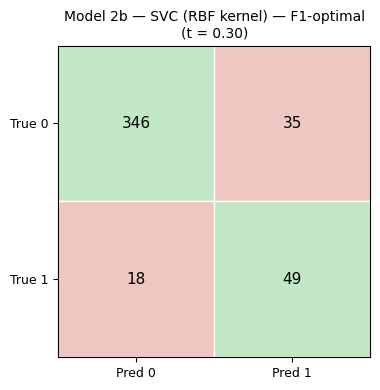

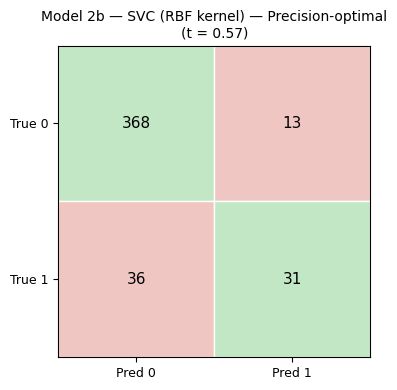

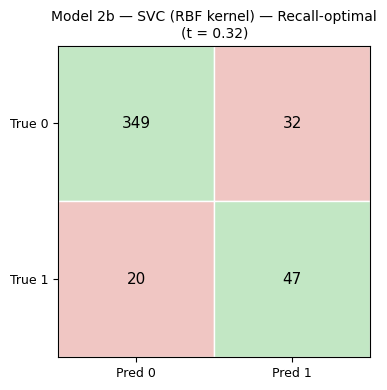


F1-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 2b — SVC (RBF kernel) — F1-optimal (t=0.30),0.8817,0.5833,0.9081,0.7313,0.649,0.9156,0.6943



Precision-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 2b — SVC (RBF kernel) — Precision-optima...,0.8906,0.7045,0.9659,0.4627,0.5586,0.9156,0.6943



Recall-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 2b — SVC (RBF kernel) — Recall-optimal (...,0.8839,0.5949,0.916,0.7015,0.6438,0.9156,0.6943


In [136]:
# ============================================
# Threshold Optimization — Model Selection
# ============================================

# Select model for threshold optimization
y_proba_best = y_proba_2b
model_label  = "Model 2b — SVC (RBF kernel)"
# ----------------------------------

# ============================================
# Threshold Optimization
# ============================================

# ---------------------
# Step D — Threshold sweep
# ---------------------
sweep_df = threshold_sweep(y_test, y_proba_best)

# Display preview only (do NOT round real values)
display(sweep_df.round(3).head())

# ---------------------
# Step E — Select thresholds by objective
# ---------------------
t_f1, name_f1 = choose_threshold_by_objective(
    sweep_df, objective="f1_max"
)

t_prec, name_prec = choose_threshold_by_objective(
    sweep_df, objective="precision_at", target=0.70
)

t_rec, name_rec = choose_threshold_by_objective(
    sweep_df, objective="recall_at", target=0.70
)

print(f"F1-optimal threshold: {t_f1:.2f} ({name_f1})")
print(f"Precision≥0.70 threshold: {t_prec:.2f} ({name_prec})")
print(f"Recall≥0.70 threshold: {t_rec:.2f} ({name_rec})")

# ---------------------
# Step F — Evaluation at selected thresholds
# ---------------------
res_f1 = show_at_threshold(
    y_test, y_proba_best, t_f1,
    f"{model_label} — F1-optimal"
)

res_prec = show_at_threshold(
    y_test, y_proba_best, t_prec,
    f"{model_label} — Precision-optimal"
)

res_rec = show_at_threshold(
    y_test, y_proba_best, t_rec,
    f"{model_label} — Recall-optimal"
)

# ---------------------
# Summary tables
# ---------------------
print("\nF1-optimal threshold metrics:")
display(pd.DataFrame([res_f1]).round(4))

print("\nPrecision-optimal threshold metrics:")
display(pd.DataFrame([res_prec]).round(4))

print("\nRecall-optimal threshold metrics:")
display(pd.DataFrame([res_rec]).round(4))


## 4.3 Model 3 — Decision Trees

This section evaluates decision tree classifiers to capture
non-linear relationships and feature interactions.

Three variants are considered:
- **Model 3a — Fully grown tree (no tuning)**
- **Model 3b — Hyperparameter-tuned tree (CV)**
- **Model 3c — Cost-complexity pruned tree (CCP)**

All models use the same preprocessing pipeline and handle class
imbalance via class weighting. Evaluation is performed at a fixed
threshold of `t = 0.50` prior to threshold optimization.


In [137]:
# ==========================================
# Model 3 — Decision Trees (Balanced)
#   3a) Full tree (no tuning)
#   3b) Tuned tree (CV)
#   3c) Pruned tree (CCP)
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

rows = []

# ============================================================
# 3a) Full Decision Tree (no tuning)
# ============================================================

pipe_tree_3a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),   # 🔒 LOCKED
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

pipe_tree_3a.fit(X_train, y_train)

y_pred_3a  = pipe_tree_3a.predict(X_test)
y_proba_3a = pipe_tree_3a.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_3a,
        y_proba_3a,
        label="Model 3a — Decision Tree (full)"
    )
)

# ============================================================
# 3b) Tuned Decision Tree (GridSearchCV)
# ============================================================

param_grid_tree = {
    "classifier__max_depth": [3, 5, 8, 12, None],
    "classifier__min_samples_split": [2, 10, 50],
    "classifier__min_samples_leaf": [1, 5, 20],
}

pipe_tree_base = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),   # 🔒 LOCKED
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

grid_tree = GridSearchCV(
    estimator=pipe_tree_base,
    param_grid=param_grid_tree,
    scoring="average_precision",
    cv=5,
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

best_tree_cv = grid_tree.best_estimator_

y_pred_3b  = best_tree_cv.predict(X_test)
y_proba_3b = best_tree_cv.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_3b,
        y_proba_3b,
        label="Model 3b — Decision Tree (tuned CV)"
    )
)

# ============================================================
# 3c) Decision Tree with CCP Pruning
# ============================================================

X_train_built = best_tree_cv.named_steps["feature_builder"].transform(X_train)
X_train_transformed = best_tree_cv.named_steps["preprocessor"].transform(
    X_train_built
)

ccp_path = best_tree_cv.named_steps["classifier"].cost_complexity_pruning_path(
    X_train_transformed,
    y_train
)

ccp_alphas = ccp_path.ccp_alphas[:-1]

param_grid_ccp = {
    "classifier__ccp_alpha": ccp_alphas
}

grid_ccp = GridSearchCV(
    estimator=pipe_tree_base,
    param_grid=param_grid_ccp,
    scoring="average_precision",
    cv=5,
    n_jobs=-1
)

grid_ccp.fit(X_train, y_train)

best_tree_ccp = grid_ccp.best_estimator_

y_pred_3c  = best_tree_ccp.predict(X_test)
y_proba_3c = best_tree_ccp.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_3c,
        y_proba_3c,
        label="Model 3c — Decision Tree (CCP pruned)"
    )
)

# ============================================================
# Compact comparison table
# ============================================================

df_model3_compare = pd.DataFrame(rows)
display(df_model3_compare)


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 3a — Decision Tree (full),0.821429,0.413333,0.884514,0.462687,0.436620,0.674913,0.472472
1,Model 3b — Decision Tree (tuned CV),0.741071,0.341935,0.732283,0.791045,0.477477,0.834058,0.542898
2,Model 3c — Decision Tree (CCP pruned),0.741071,0.333333,0.742782,0.731343,0.457944,0.801034,0.386766


### 4.3.1 Decision Threshold Optimization (Model 3b)
Predicted probabilities are fixed and evaluated across multiple thresholds
to support different business objectives.

,threshold,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,0.01,0.574,0.248,0.514,0.91,0.39,0.834,0.543
1,0.02,0.574,0.248,0.514,0.91,0.39,0.834,0.543
2,0.03,0.574,0.248,0.514,0.91,0.39,0.834,0.543
3,0.04,0.574,0.248,0.514,0.91,0.39,0.834,0.543
4,0.05,0.574,0.248,0.514,0.91,0.39,0.834,0.543


F1-optimal threshold: 0.72 (F1-max)
Precision≥0.70 threshold: 0.91 (precision≥0.7, max recall)
Recall≥0.70 threshold: 0.63 (recall≥0.7, max precision)


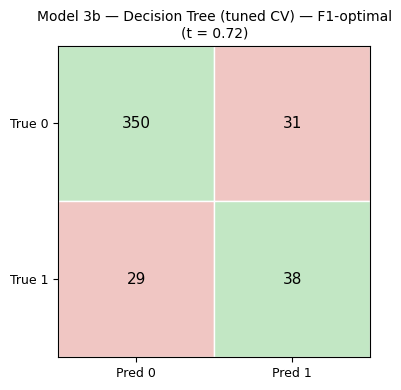

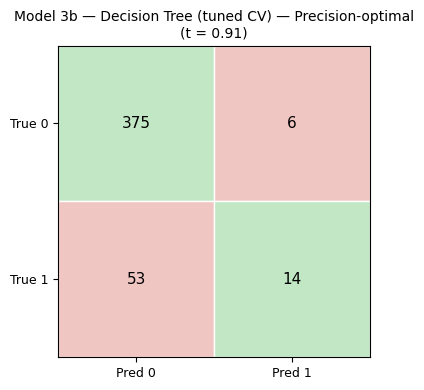

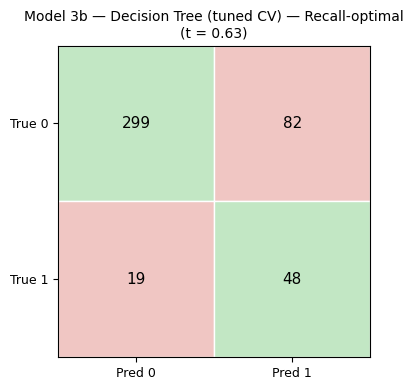


F1-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 3b — Decision Tree (tuned CV) — F1-optim...,0.8661,0.5507,0.9186,0.5672,0.5588,0.8341,0.5429



Precision-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 3b — Decision Tree (tuned CV) — Precisio...,0.8683,0.7,0.9843,0.209,0.3218,0.8341,0.5429



Recall-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 3b — Decision Tree (tuned CV) — Recall-o...,0.7746,0.3692,0.7848,0.7164,0.4873,0.8341,0.5429


In [138]:
# ============================================
# Threshold Optimization — Model Selection
# ============================================

# Select model for threshold optimization
y_proba_best = y_proba_3b
model_label  = "Model 3b — Decision Tree (tuned CV)"
# ----------------------------------

# ============================================
# Threshold Optimization
# ============================================

# ---------------------
# Step D — Threshold sweep
# ---------------------
sweep_df = threshold_sweep(y_test, y_proba_best)

# Display preview only (do NOT round real values)
display(sweep_df.round(3).head())

# ---------------------
# Step E — Select thresholds by objective
# ---------------------
t_f1, name_f1 = choose_threshold_by_objective(
    sweep_df, objective="f1_max"
)

t_prec, name_prec = choose_threshold_by_objective(
    sweep_df, objective="precision_at", target=0.70
)

t_rec, name_rec = choose_threshold_by_objective(
    sweep_df, objective="recall_at", target=0.70
)

print(f"F1-optimal threshold: {t_f1:.2f} ({name_f1})")
print(f"Precision≥0.70 threshold: {t_prec:.2f} ({name_prec})")
print(f"Recall≥0.70 threshold: {t_rec:.2f} ({name_rec})")

# ---------------------
# Step F — Evaluation at selected thresholds
# ---------------------
res_f1 = show_at_threshold(
    y_test, y_proba_best, t_f1,
    f"{model_label} — F1-optimal"
)

res_prec = show_at_threshold(
    y_test, y_proba_best, t_prec,
    f"{model_label} — Precision-optimal"
)

res_rec = show_at_threshold(
    y_test, y_proba_best, t_rec,
    f"{model_label} — Recall-optimal"
)

# ---------------------
# Summary tables
# ---------------------
print("\nF1-optimal threshold metrics:")
display(pd.DataFrame([res_f1]).round(4))

print("\nPrecision-optimal threshold metrics:")
display(pd.DataFrame([res_prec]).round(4))

print("\nRecall-optimal threshold metrics:")
display(pd.DataFrame([res_rec]).round(4))


## 4.4 Model 4 — Random Forest

This section evaluates Random Forest classifiers as ensemble-based,
non-linear models.

Two variants are considered:
- **Model 4a — Baseline Random Forest**
- **Model 4b — Fast-tuned Random Forest (CV)**

Evaluation is performed at a fixed threshold of `t = 0.50` prior to
decision threshold optimization.


In [139]:
# ==========================================
# Model 4 — Random Forest (Balanced)
#   4a) Baseline Random Forest
#   4b) Fast-tuned Random Forest (CV)
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rows = []

# ============================================================
# 4a) Random Forest — Baseline
# ============================================================

pipe_rf_4a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),   # 🔒 LOCKED
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

pipe_rf_4a.fit(X_train, y_train)

y_pred_4a  = pipe_rf_4a.predict(X_test)
y_proba_4a = pipe_rf_4a.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_4a,
        y_proba_4a,
        label="Model 4a — Random Forest (baseline)"
    )
)

# ============================================================
# 4b) Random Forest — Fast tuning (GridSearchCV)
# ============================================================

param_grid_rf = {
    "classifier__n_estimators": [300, 500],
    "classifier__max_depth": [None, 8, 15],
    "classifier__min_samples_leaf": [1, 5, 20],
}

pipe_rf_base = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),   # 🔒 LOCKED
    ("classifier", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

grid_rf = GridSearchCV(
    estimator=pipe_rf_base,
    param_grid=param_grid_rf,
    scoring="average_precision",
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

y_pred_4b  = best_rf.predict(X_test)
y_proba_4b = best_rf.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_4b,
        y_proba_4b,
        label="Model 4b — Random Forest (fast tuned)"
    )
)

# ============================================================
# Compact comparison table
# ============================================================

df_model4_compare = pd.DataFrame(rows)
display(df_model4_compare)


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 4a — Random Forest (baseline),0.877232,0.687500,0.973753,0.328358,0.444444,0.900165,0.599380
1,Model 4b — Random Forest (fast tuned),0.879464,0.591549,0.923885,0.626866,0.608696,0.908587,0.671268


### 4.4.1 Decision Threshold Optimization (Model 4b)
Predicted probabilities are fixed and evaluated across multiple thresholds
to support different business objectives.

,threshold,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,0.01,0.172,0.153,0.026,1.0,0.265,0.909,0.671
1,0.02,0.194,0.157,0.052,1.0,0.271,0.909,0.671
2,0.03,0.232,0.163,0.097,1.0,0.280,0.909,0.671
3,0.04,0.263,0.169,0.134,1.0,0.289,0.909,0.671
4,0.05,0.317,0.180,0.197,1.0,0.305,0.909,0.671


F1-optimal threshold: 0.46 (F1-max)
Precision≥0.70 threshold: 0.54 (precision≥0.7, max recall)
Recall≥0.70 threshold: 0.47 (recall≥0.7, max precision)


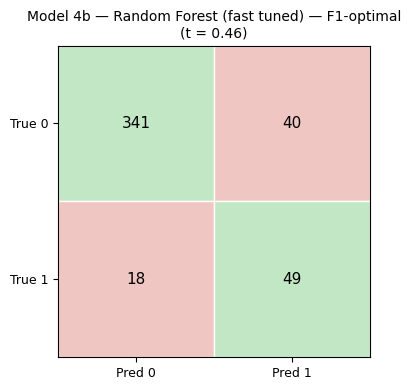

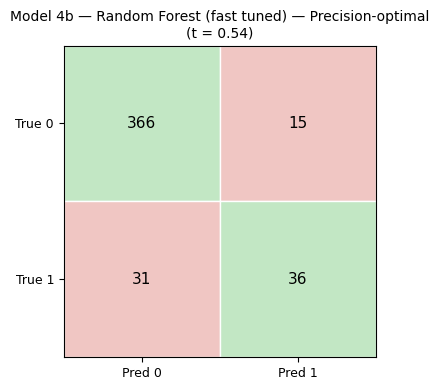

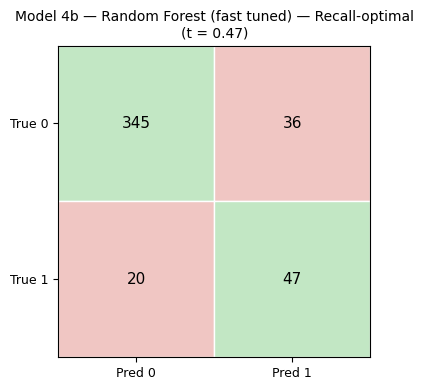


F1-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 4b — Random Forest (fast tuned) — F1-opt...,0.8705,0.5506,0.895,0.7313,0.6282,0.9086,0.6713



Precision-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 4b — Random Forest (fast tuned) — Precis...,0.8973,0.7059,0.9606,0.5373,0.6102,0.9086,0.6713



Recall-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 4b — Random Forest (fast tuned) — Recall...,0.875,0.5663,0.9055,0.7015,0.6267,0.9086,0.6713


In [140]:
# ============================================
# Threshold Optimization — Model Selection
# ============================================

# Select model for threshold optimization
y_proba_best = y_proba_4b
model_label  = "Model 4b — Random Forest (fast tuned)"
# ----------------------------------

# ============================================
# Threshold Optimization
# ============================================

# ---------------------
# Step D — Threshold sweep
# ---------------------
sweep_df = threshold_sweep(y_test, y_proba_best)

# Display preview only (do NOT round real values)
display(sweep_df.round(3).head())

# ---------------------
# Step E — Select thresholds by objective
# ---------------------
t_f1, name_f1 = choose_threshold_by_objective(
    sweep_df, objective="f1_max"
)

t_prec, name_prec = choose_threshold_by_objective(
    sweep_df, objective="precision_at", target=0.70
)

t_rec, name_rec = choose_threshold_by_objective(
    sweep_df, objective="recall_at", target=0.70
)

print(f"F1-optimal threshold: {t_f1:.2f} ({name_f1})")
print(f"Precision≥0.70 threshold: {t_prec:.2f} ({name_prec})")
print(f"Recall≥0.70 threshold: {t_rec:.2f} ({name_rec})")

# ---------------------
# Step F — Evaluation at selected thresholds
# ---------------------
res_f1 = show_at_threshold(
    y_test, y_proba_best, t_f1,
    f"{model_label} — F1-optimal"
)

res_prec = show_at_threshold(
    y_test, y_proba_best, t_prec,
    f"{model_label} — Precision-optimal"
)

res_rec = show_at_threshold(
    y_test, y_proba_best, t_rec,
    f"{model_label} — Recall-optimal"
)

# ---------------------
# Summary tables
# ---------------------
print("\nF1-optimal threshold metrics:")
display(pd.DataFrame([res_f1]).round(4))

print("\nPrecision-optimal threshold metrics:")
display(pd.DataFrame([res_prec]).round(4))

print("\nRecall-optimal threshold metrics:")
display(pd.DataFrame([res_rec]).round(4))


## 4.5 Model 5 — Boosting Models

This section evaluates boosting-based classifiers that sequentially
combine weak learners to improve predictive performance.

Two variants are considered:
- **Model 5a — Gradient Boosting**
- **Model 5b — XGBoost (fast tuned)**

All models are evaluated at a fixed threshold of `t = 0.50` prior to
decision threshold optimization.

In [141]:
# ==========================================
# Model 5 — Boosting Models (Balanced)
#   5a) Gradient Boosting (baseline)
#   5b) XGBoost (fast tuned)
# ==========================================

from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

rows = []

# ============================================================
# 5a) Gradient Boosting — Baseline
# ============================================================

pipe_gb_5a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),   # 🔒 LOCKED
    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))
])

pipe_gb_5a.fit(X_train, y_train)

y_pred_5a  = pipe_gb_5a.predict(X_test)
y_proba_5a = pipe_gb_5a.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_5a,
        y_proba_5a,
        label="Model 5a — Gradient Boosting"
    )
)

# ============================================================
# 5b) XGBoost — Fast tuning (CV)
# ============================================================

pipe_xgb_base = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_tree),   # 🔒 LOCKED
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    ))
])

param_grid_xgb = {
    "classifier__n_estimators": [300, 500],
    "classifier__max_depth": [3, 5],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    estimator=pipe_xgb_base,
    param_grid=param_grid_xgb,
    scoring="average_precision",
    cv=5,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

y_pred_5b  = best_xgb.predict(X_test)
y_proba_5b = best_xgb.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_5b,
        y_proba_5b,
        label="Model 5b — XGBoost (fast tuned)"
    )
)

# ============================================================
# Compact comparison table
# ============================================================

df_model5_compare = pd.DataFrame(rows)
display(df_model5_compare)


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 5a — Gradient Boosting,0.892857,0.771429,0.979003,0.402985,0.529412,0.899929,0.639653
1,Model 5b — XGBoost (fast tuned),0.852679,0.505051,0.871391,0.746269,0.602410,0.913014,0.684185


### 4.5.1 Decision Threshold Optimization (Model 5b)
Predicted probabilities are fixed and evaluated across multiple thresholds
to support different business objectives.

,threshold,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,0.01,0.268,0.170,0.139,1.0,0.290,0.913,0.684
1,0.02,0.346,0.186,0.231,1.0,0.314,0.913,0.684
2,0.03,0.402,0.200,0.297,1.0,0.333,0.913,0.684
3,0.04,0.449,0.213,0.352,1.0,0.352,0.913,0.684
4,0.05,0.480,0.223,0.388,1.0,0.365,0.913,0.684


F1-optimal threshold: 0.63 (F1-max)
Precision≥0.70 threshold: 0.78 (precision≥0.7, max recall)
Recall≥0.70 threshold: 0.59 (recall≥0.7, max precision)


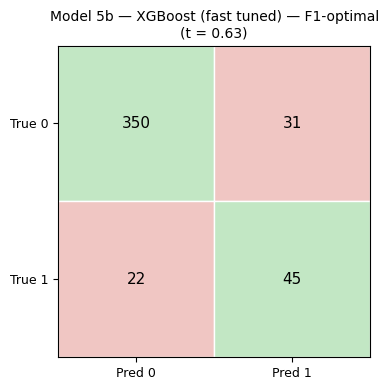

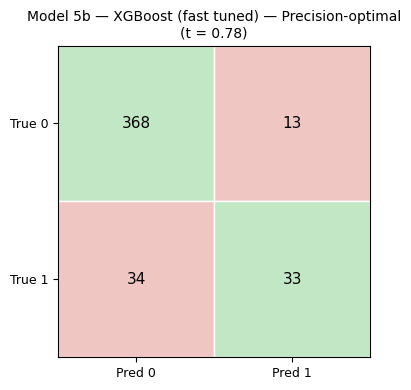

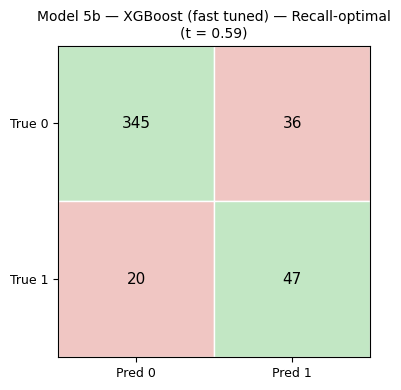


F1-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 5b — XGBoost (fast tuned) — F1-optimal (...,0.8817,0.5921,0.9186,0.6716,0.6294,0.913,0.6842



Precision-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 5b — XGBoost (fast tuned) — Precision-op...,0.8951,0.7174,0.9659,0.4925,0.5841,0.913,0.6842



Recall-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,Model 5b — XGBoost (fast tuned) — Recall-optim...,0.875,0.5663,0.9055,0.7015,0.6267,0.913,0.6842


In [142]:
# ============================================
# Threshold Optimization — Model Selection
# ============================================

# Select model for threshold optimization
y_proba_best = y_proba_5b
model_label  = "Model 5b — XGBoost (fast tuned)"
# ----------------------------------

# ============================================
# Threshold Optimization
# ============================================

# ---------------------
# Step D — Threshold sweep
# ---------------------
sweep_df = threshold_sweep(y_test, y_proba_best)

# Display preview only (do NOT round real values)
display(sweep_df.round(3).head())

# ---------------------
# Step E — Select thresholds by objective
# ---------------------
t_f1, name_f1 = choose_threshold_by_objective(
    sweep_df, objective="f1_max"
)

t_prec, name_prec = choose_threshold_by_objective(
    sweep_df, objective="precision_at", target=0.70
)

t_rec, name_rec = choose_threshold_by_objective(
    sweep_df, objective="recall_at", target=0.70
)

print(f"F1-optimal threshold: {t_f1:.2f} ({name_f1})")
print(f"Precision≥0.70 threshold: {t_prec:.2f} ({name_prec})")
print(f"Recall≥0.70 threshold: {t_rec:.2f} ({name_rec})")

# ---------------------
# Step F — Evaluation at selected thresholds
# ---------------------
res_f1 = show_at_threshold(
    y_test, y_proba_best, t_f1,
    f"{model_label} — F1-optimal"
)

res_prec = show_at_threshold(
    y_test, y_proba_best, t_prec,
    f"{model_label} — Precision-optimal"
)

res_rec = show_at_threshold(
    y_test, y_proba_best, t_rec,
    f"{model_label} — Recall-optimal"
)

# ---------------------
# Summary tables
# ---------------------
print("\nF1-optimal threshold metrics:")
display(pd.DataFrame([res_f1]).round(4))

print("\nPrecision-optimal threshold metrics:")
display(pd.DataFrame([res_prec]).round(4))

print("\nRecall-optimal threshold metrics:")
display(pd.DataFrame([res_rec]).round(4))


### 4.6 Model 6 — Logistic Regression with Polynomial Features

This section evaluates logistic regression models augmented with polynomial feature interactions in order to capture non-linear relationships between numeric predictors while maintaining a probabilistic classification framework.

Polynomial feature expansion is applied exclusively to selected numeric features and is handled inside a dedicated preprocessing pipeline to ensure leakage-safe transformations. Interaction-only terms are used to limit feature explosion and control model complexity.

Three variants are considered:

- **Model 6a — Polynomial Logistic Regression (no regularization)**
A baseline polynomial-augmented logistic model without explicit regularization, serving as a reference point for assessing overfitting in the expanded feature space.

- **Model 6b — Polynomial Logistic Regression with L2 regularization (CV)**
A ridge-regularized polynomial logistic model, with the regularization strength selected via cross-validation to balance bias and variance.

- **Model 6c — Polynomial Logistic Regression with L1 regularization (CV)**
A lasso-regularized polynomial logistic model that performs implicit feature selection by driving less informative interaction terms to zero.

All models in this section are evaluated on the test set using a fixed decision threshold of t = 0.50, with ROC-AUC used as the primary comparison metric prior to any threshold optimization.

In [152]:
# ============================================================
# Model 6 — Logistic Regression with Polynomial Features (Balanced)
#   6a) Polynomial Logistic (no regularization)
#   6b) Polynomial Logistic + L2 (CV)
#   6c) Polynomial Logistic + L1 (CV)
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

rows = []

# ============================================================
# 6a) Polynomial Logistic — no regularization
# ============================================================

pipe_logit_6a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_poly_logistic),   # 🔒 LOCKED (poly)
    ("classifier", LogisticRegression(
        penalty=None,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=3000
    ))
])

pipe_logit_6a.fit(X_train, y_train)

y_pred_6a  = pipe_logit_6a.predict(X_test)
y_proba_6a = pipe_logit_6a.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_6a,
        y_proba_6a,
        label="Model 6a — Poly Logistic (balanced, no regularization)"
    )
)

# ============================================================
# 6b) Polynomial Logistic — L2 regularization (CV)
# ============================================================

pipe_logit_6b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_poly_logistic),   # 🔒 LOCKED (poly)
    ("classifier", LogisticRegressionCV(
        Cs=10,
        cv=5,
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
        scoring="average_precision",
        max_iter=3000,
        n_jobs=-1
    ))
])

pipe_logit_6b.fit(X_train, y_train)

y_pred_6b  = pipe_logit_6b.predict(X_test)
y_proba_6b = pipe_logit_6b.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_6b,
        y_proba_6b,
        label="Model 6b — Poly Logistic L2 (balanced, CV)"
    )
)

# ============================================================
# 6c) Polynomial Logistic — L1 regularization (CV)
# ============================================================

pipe_logit_6c = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_poly_logistic),   # 🔒 LOCKED (poly)
    ("classifier", LogisticRegressionCV(
        Cs=10,
        cv=5,
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        scoring="average_precision",
        max_iter=3000,
        n_jobs=-1
    ))
])

pipe_logit_6c.fit(X_train, y_train)

y_pred_6c  = pipe_logit_6c.predict(X_test)
y_proba_6c = pipe_logit_6c.predict_proba(X_test)[:, 1]

rows.append(
    metric_report(
        y_test,
        y_pred_6c,
        y_proba_6c,
        label="Model 6c — Poly Logistic L1 (balanced, CV)"
    )
)

# ============================================================
# Compact comparison table (t = 0.50)
# ============================================================

df_model6_compare = pd.DataFrame(rows)
display(df_model6_compare)


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,"Model 6a — Poly Logistic (balanced, no regular...",0.801339,0.417910,0.795276,0.835821,0.557214,0.899969,0.629033
1,"Model 6b — Poly Logistic L2 (balanced, CV)",0.808036,0.426357,0.805774,0.820896,0.561224,0.898167,0.629613
2,"Model 6c — Poly Logistic L1 (balanced, CV)",0.808036,0.427481,0.803150,0.835821,0.565657,0.898637,0.629772


,threshold,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,0.01,0.288,0.174,0.163,1.0,0.296,0.899,0.63
1,0.02,0.333,0.183,0.215,1.0,0.309,0.899,0.63
2,0.03,0.373,0.193,0.262,1.0,0.323,0.899,0.63
3,0.04,0.426,0.207,0.325,1.0,0.343,0.899,0.63
4,0.05,0.451,0.214,0.354,1.0,0.353,0.899,0.63


F1-optimal threshold: 0.70 (F1-max)
Precision≥0.70 threshold: 0.90 (precision≥0.7, max recall)
Recall≥0.70 threshold: 0.62 (recall≥0.7, max precision)


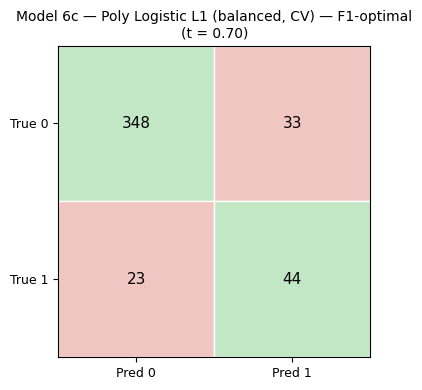

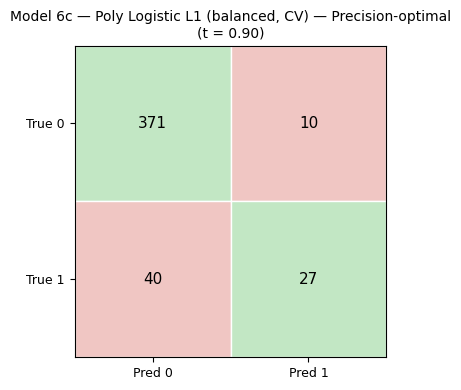

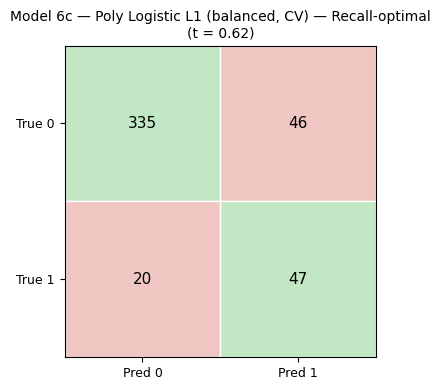


F1-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,"Model 6c — Poly Logistic L1 (balanced, CV) — F...",0.875,0.5714,0.9134,0.6567,0.6111,0.8986,0.6298



Precision-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,"Model 6c — Poly Logistic L1 (balanced, CV) — P...",0.8884,0.7297,0.9738,0.403,0.5192,0.8986,0.6298



Recall-optimal threshold metrics:


,model,accuracy,precision,specificity,recall,f1,roc_auc,pr_auc
0,"Model 6c — Poly Logistic L1 (balanced, CV) — R...",0.8527,0.5054,0.8793,0.7015,0.5875,0.8986,0.6298


In [153]:
# ============================================
# Threshold Optimization — Model Selection
# ============================================

# Select model for threshold optimization
y_proba_best = y_proba_6c
model_label  = "Model 6c — Poly Logistic L1 (balanced, CV)"
# ----------------------------------

# ============================================
# Threshold Optimization
# ============================================

# ---------------------
# Step D — Threshold sweep
# ---------------------
sweep_df = threshold_sweep(y_test, y_proba_best)

# Display preview only (do NOT round real values)
display(sweep_df.round(3).head())

# ---------------------
# Step E — Select thresholds by objective
# ---------------------
t_f1, name_f1 = choose_threshold_by_objective(
    sweep_df, objective="f1_max"
)

t_prec, name_prec = choose_threshold_by_objective(
    sweep_df, objective="precision_at", target=0.70
)

t_rec, name_rec = choose_threshold_by_objective(
    sweep_df, objective="recall_at", target=0.70
)

print(f"F1-optimal threshold: {t_f1:.2f} ({name_f1})")
print(f"Precision≥0.70 threshold: {t_prec:.2f} ({name_prec})")
print(f"Recall≥0.70 threshold: {t_rec:.2f} ({name_rec})")

# ---------------------
# Step F — Evaluation at selected thresholds
# ---------------------
res_f1 = show_at_threshold(
    y_test, y_proba_best, t_f1,
    f"{model_label} — F1-optimal"
)

res_prec = show_at_threshold(
    y_test, y_proba_best, t_prec,
    f"{model_label} — Precision-optimal"
)

res_rec = show_at_threshold(
    y_test, y_proba_best, t_rec,
    f"{model_label} — Recall-optimal"
)

# ---------------------
# Summary tables
# ---------------------
print("\nF1-optimal threshold metrics:")
display(pd.DataFrame([res_f1]).round(4))

print("\nPrecision-optimal threshold metrics:")
display(pd.DataFrame([res_prec]).round(4))

print("\nRecall-optimal threshold metrics:")
display(pd.DataFrame([res_rec]).round(4))

## 5. Final Model Comparison — PR-AUC Ranking

In [158]:
# ==========================================
# Final Model Comparison — PR-AUC ranked
# SAME metrics + SAME family colors
# ==========================================

import pandas as pd
from IPython.display import display, HTML

# ------------------------------------------------------------
# 1) Combine model result tables
# ------------------------------------------------------------
dfs = [
    df_model1_compare,
    df_model2_compare,
    df_model3_compare,
    df_model4_compare,
    df_model5_compare,
    df_model6_compare,   # Poly Logistic
]

df_all = pd.concat(dfs, ignore_index=True)

# ------------------------------------------------------------
# 2) Rank by PR-AUC
# ------------------------------------------------------------
df_ranked = (
    df_all
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3) True algorithmic family
# ------------------------------------------------------------
def extract_family(model_name):
    if model_name.startswith("Model 1") or model_name.startswith("Model 6"):
        return "Logistic"
    if model_name.startswith("Model 2"):
        return "SVM"
    if model_name.startswith("Model 3"):
        return "Decision Tree"
    if model_name.startswith("Model 4"):
        return "Random Forest"
    if model_name.startswith("Model 5"):
        return "Boosting"
    return "Other"

df_ranked["Family"] = df_ranked["model"].apply(extract_family)

# ------------------------------------------------------------
# 4) EXACT SAME COLORS
# ------------------------------------------------------------
family_colors = {
    "Logistic":       "#D5B6DA",
    "SVM":            "#C5CCD1",
    "Decision Tree":  "#E8F5E9",
    "Random Forest":  "#FFFDE7",
    "Boosting":       "#FBE9E7",
}

def highlight_family(row):
    color = family_colors.get(row["Family"], "#FFFFFF")
    return [f"background-color: {color}"] * len(row)

# ------------------------------------------------------------
# 5) Highlight PR-AUC column
# ------------------------------------------------------------
def highlight_pr_auc(col):
    return [
        "background-color: #FFCDD2; font-weight:600"
        if col.name == "pr_auc" else ""
        for _ in col
    ]

# ----------------------------------
# 6) Add family icon tags
# ----------------------------------

family_icon = {
    "Logistic": "🟣",
    "Poly Logistic": "🟣",
    "SGD Logistic": "🔵",
    "SVM": "🔵",
    "Decision Tree": "🟢",
    "Random Forest": "🟡",
    "Boosting": "🟠",
    "KNN": "🟤"
}

df_ranked["FamilyTag"] = df_ranked["Family"].map(family_icon).fillna("⬜")


# ------------------------------------------------------------
# 7) Styled table (Family NOT shown, but used)
# ------------------------------------------------------------
styled_df = (
    df_ranked[
        [
            "model",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
            "Family", 
            "FamilyTag"  # 👈 MUST stay here for styling
        ]
    ]
    .style
    .apply(highlight_family, axis=1)
    .apply(highlight_pr_auc, axis=0)
    .format({
        "accuracy": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "roc_auc": "{:.3f}",
        "pr_auc": "{:.3f}",
    })
    #.hide(axis="columns", subset=["Family"])   # 👈 hide visually
)

display(HTML("""
<h3 style="text-align:center; font-weight:600; margin-bottom:6px;">
Final Model Comparison — Ranked by PR-AUC
</h3>
"""))

display(styled_df)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,Family,FamilyTag
0,Model 2b — RBF SVM (balanced),0.844,0.487,0.851,0.620,0.916,0.694,SVM,🔵
1,Model 5b — XGBoost (fast tuned),0.853,0.505,0.746,0.602,0.913,0.684,Boosting,🟠
2,Model 4b — Random Forest (fast tuned),0.879,0.592,0.627,0.609,0.909,0.671,Random Forest,🟡
3,"Model 1b — Logistic L2 (balanced, CV)",0.824,0.450,0.806,0.578,0.896,0.642,Logistic,🟣
4,"Model 1c — Logistic L1 (balanced, CV)",0.824,0.450,0.806,0.578,0.895,0.640,Logistic,🟣
5,"Model 1a — Logistic (balanced, no regularization)",0.826,0.454,0.806,0.581,0.895,0.640,Logistic,🟣
6,Model 5a — Gradient Boosting,0.893,0.771,0.403,0.529,0.900,0.640,Boosting,🟠
7,"Model 6c — Poly Logistic L1 (balanced, CV)",0.808,0.427,0.836,0.566,0.899,0.630,Logistic,🟣
8,"Model 6b — Poly Logistic L2 (balanced, CV)",0.808,0.426,0.821,0.561,0.898,0.630,Logistic,🟣
9,"Model 6a — Poly Logistic (balanced, no regularization)",0.801,0.418,0.836,0.557,0.900,0.629,Logistic,🟣
